In [7]:
import pandas as pd
import glob
import os

base_folder = r"C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok"
years = ["2022", "2023", "2024"]

dfs = []

pattern = r'^\d{4}-'

for year in years:
    folder_path = os.path.join(base_folder, year)
    file_list = glob.glob(os.path.join(folder_path, "*.xlsx"))
    print(f"{year}: {len(file_list)} fájl található")

    for file in file_list:
        print("Beolvasás:", file)
        temp_df = pd.read_excel(file)
        temp_df["year"] = int(year)
        mask = (
            temp_df['start_place_id'].astype(str).str.match(pattern) &
            temp_df['end_place_id'].astype(str).str.match(pattern)
        )
        temp_df = temp_df[mask]

        cols = ['start_time', 'end_time', 'duration', 'start_place_id', 'end_place_id',
                'start_lat', 'start_lng', 'end_lat', 'end_lng',
                'cust_id', 'bike_id', 'coupon_name', 'year']
        temp_df = temp_df[cols]

        dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)
print("Összes sor beolvasva és szűrve:", len(df))

df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
df = df.dropna(subset=['start_time', 'end_time'])

df['duration_min'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60
df = df[(df['duration_min'] > 0) & (df['duration_min'] < 120)]

2022: 12 fájl található
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_01.xlsx
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_02.xlsx
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_03.xlsx
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_04.xlsx
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_05.xlsx
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_06.xlsx
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_07.xlsx
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_08.xlsx
Beolvasás: C:\Users\Huawei\Desktop\témalab1\Bubi-data-analyzis---T-malabor1\code\Adatok\2022\2022_09.xlsx
Beolvasás: C:\Users\Hu

In [3]:
import pandas as pd
df.to_pickle("bubi_all_years.pkl")

NameError: name 'df' is not defined

In [7]:
df = pd.read_pickle("bubi_all_years.pkl")


Csonka János tér (2022-06-15) – Inflow table
                                start_place_id  count  percentage
79                 1107-Móricz Zsigmond körtér     55        8.08
99                       1128-Csonka János tér     44        6.46
92                          1120-Budapart Gate     30        4.41
81                       1109-Újbuda-központ M     29        4.26
102  1131-Kelenföld vasútállomás M (Etele tér)     24        3.52
96                           1125-Bikás park M     22        3.23
80            1108-Pázmány Péter sétány - ELTE     18        2.64
100    1129-Bogdánfy utca - Neumann János utca     17        2.50
64                             0906-Ferenc tér     17        2.50
91                    1119-Infopark - aluljáró     16        2.35

Csonka János tér (2022-06-15) – Outflow table
                                 end_place_id  count  percentage
85                         1120-Budapart Gate     48        6.82
93                      1128-Csonka János tér     4

NameError: name 'os' is not defined

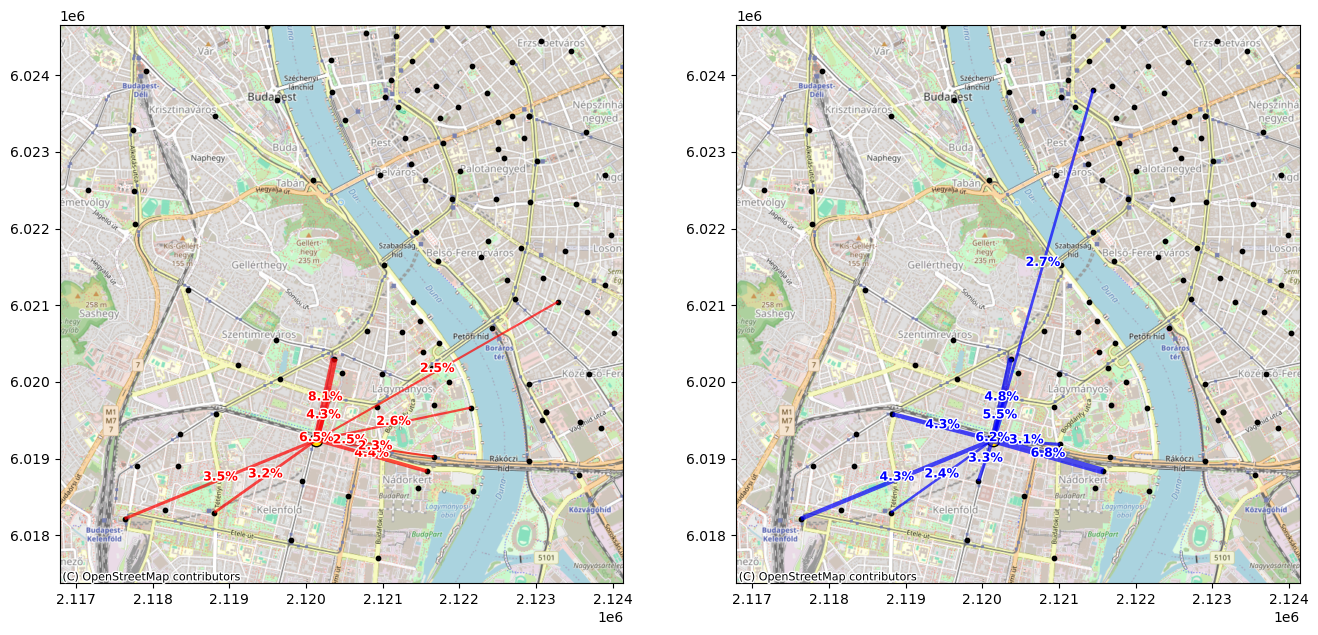

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point, LineString
import geopandas as gpd
import matplotlib.patheffects as path_effects

df = pd.read_pickle("bubi_all_years.pkl")

families = {
    "Csonka János tér (2022-06-15)": {"names": ["Csonka János tér"], "start": "2022-06-15"},
    "Zugló – Sportaréna (2023-06-28)": {"names": ["Sportaréna"], "start": "2023-06-28"},
    "Zugló – Vasútállomás (2023-06-28)": {"names": ["Zugló vasútállomás"], "start": "2023-06-28"},
    "9. kerület – Haller–Mester (2023-09-01)": {"names": ["Haller utca", "Mester utca"], "start": "2023-09-01"},
    "Kopaszi-gát (2024-04-09)": {"names": ["Kopaszi"], "start": "2024-04-09"},
    "Westend – Balzac utca (2024-05-01)": {"names": ["Westend", "Balzac"], "start": "2024-05-01"}
}

df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')

def get_station_coords(df):
    start_coords = df.groupby('start_place_id')[['start_lat', 'start_lng']].mean().rename(
        columns={'start_lat': 'lat', 'start_lng': 'lng'})
    end_coords = df.groupby('end_place_id')[['end_lat', 'end_lng']].mean().rename(
        columns={'end_lat': 'lat', 'end_lng': 'lng'})
    all_coords = pd.concat([start_coords, end_coords]).groupby(level=0).mean()
    return all_coords

station_coords = get_station_coords(df)

for family_name, data in families.items():
    start_date = pd.to_datetime(data['start'])
    end_date = start_date + pd.Timedelta(days=30)
    names = data['names']
    pattern = "|".join(names)

    df_period = df[(df['start_time'] >= start_date) & (df['start_time'] < end_date)]

    mask_in = df_period['end_place_id'].str.contains(pattern, case=False, na=False)
    mask_out = df_period['start_place_id'].str.contains(pattern, case=False, na=False)

    incoming = (
    df_period[mask_in]
    .groupby('start_place_id')
    .size()
    .reset_index(name='count'))

    total_in = incoming['count'].sum()

    incoming['percentage'] = incoming['count'] / total_in * 100

    incoming = (
        incoming
        .sort_values('count', ascending=False)
        .head(10))

    
    outgoing = (
    df_period[mask_out]
    .groupby('end_place_id')
    .size()
    .reset_index(name='count'))

    total_out = outgoing['count'].sum()

    outgoing['percentage'] = outgoing['count'] / total_out * 100

    outgoing = (
        outgoing
        .sort_values('count', ascending=False)
        .head(10))

    print(f"\n{family_name} – Inflow table")
    print(incoming.round({'percentage': 2}))

    print(f"\n{family_name} – Outflow table")
    print(outgoing.round({'percentage': 2}))


    if incoming.empty and outgoing.empty:
        print(f"{family_name}: nincs adat a 90 napos időszakban.")
        continue

    cluster_stations = [s for s in station_coords.index if any(n.lower() in s.lower() for n in names)]
    cluster_lat = station_coords.loc[cluster_stations, 'lat'].mean()
    cluster_lng = station_coords.loc[cluster_stations, 'lng'].mean()
    station_coords.loc[family_name] = [cluster_lat, cluster_lng]

    edges = []

    for _, row in incoming.iterrows():
        src = row['start_place_id']
        tgt = family_name
        c = row['count']
        pct = row['percentage']
        if src in station_coords.index:
            edges.append((src, tgt, c, pct, "in"))

    for _, row in outgoing.iterrows():
        src = family_name
        tgt = row['end_place_id']
        c = row['count']
        pct = row['percentage']
        if tgt in station_coords.index:
            edges.append((src, tgt, c, pct, "out"))


    if not edges:
        print(f"{family_name}: nincs megjeleníthető él.")
        continue

    edge_geoms = []
    
    for src, tgt, c, pct, direction in edges:
        p1 = Point(station_coords.loc[src, ['lng', 'lat']])
        p2 = Point(station_coords.loc[tgt, ['lng', 'lat']])
    
        edge_geoms.append({
            "u": src,
            "v": tgt,
            "weight": c,
            "percentage": pct,
            "direction": direction,
            "geometry": LineString([p1, p2])
        })
    
    gdf_edges = gpd.GeoDataFrame(edge_geoms, crs="EPSG:4326").to_crs(3857)

    gdf_nodes = gpd.GeoDataFrame(
        station_coords, geometry=gpd.points_from_xy(station_coords.lng, station_coords.lat), crs="EPSG:4326"
    ).to_crs(3857)

    fig, (ax_in, ax_out) = plt.subplots(1, 2, figsize=(16, 8))

    gdf_in = gdf_edges[gdf_edges['direction'] == 'in']
    gdf_in.plot(ax=ax_in, color='red', linewidth=(gdf_in['weight'] / gdf_in['weight'].max()) * 5, alpha=0.7)
    for _, row in gdf_in.iterrows():
        x, y = row.geometry.interpolate(0.5, normalized=True).xy
        label = f"{row.percentage:.1f}%"   # <-- only percentage
        ax_in.text(
            x[0], y[0] + 30, label,
            fontsize=9, color='red', ha='center', va='center', fontweight='bold',
            path_effects=[path_effects.withStroke(linewidth=2,foreground='white')],)

    gdf_out = gdf_edges[gdf_edges['direction'] == 'out']
    gdf_out.plot(ax=ax_out, color='blue', linewidth=(gdf_out['weight'] / gdf_out['weight'].max()) * 5, alpha=0.7)
    for _, row in gdf_out.iterrows():
        x, y = row.geometry.interpolate(0.5, normalized=True).xy
        label = f"{row.percentage:.1f}%"   # <-- only percentage
        ax_out.text(
            x[0], y[0] + 30, label,
            fontsize=9, color='blue', ha='center', va='center', fontweight='bold',
            path_effects=[path_effects.withStroke(linewidth=2,foreground='white')],)


    for ax in [ax_in, ax_out]:
        gdf_nodes.plot(ax=ax, color='black', markersize=10)
        ax.scatter(*gdf_nodes.loc[family_name, 'geometry'].coords[0], color='gold', s=80, edgecolor='black')

        xmin, ymin, xmax, ymax = gdf_edges.total_bounds
        dx = (xmax - xmin) * 0.15
        dy = (ymax - ymin) * 0.15
        ax.set_xlim(xmin - dx, xmax + dx)
        ax.set_ylim(ymin - dy, ymax + dy)

        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    os.makedirs("results", exist_ok=True)
    with pd.ExcelWriter(f"results/{family_name}_flows.xlsx") as writer:
        incoming.to_excel(writer, sheet_name="Inflow", index=False, float_format="%.2f")
        outgoing.to_excel(writer, sheet_name="Outflow", index=False, float_format="%.2f")

    ax_in.set_title(f"{family_name} – Top 10 inflow", fontsize=13, color='red')
    ax_out.set_title(f"{family_name} – Top 10 outflow", fontsize=13, color='blue')

    plt.tight_layout()
    plt.savefig(f"{family_name.replace(' ', '_').replace('–','-')}_graph_split.png", dpi=300)
    plt.close(fig)
    print(f"{family_name} mentve (in/out külön ábrázolva).")




In [ ]:
import pandas as pd
import networkx as nx

df = pd.read_pickle("bubi_all_years.pkl")

edge_weights = (
    df.groupby(['start_place_id', 'end_place_id'])
      .size()
      .reset_index(name='weight'))

G = nx.DiGraph()

for _, row in edge_weights.iterrows():
    u = row['start_place_id']
    v = row['end_place_id']
    w = row['weight']
    G.add_edge(u, v, weight=w)

print("Csúcsok száma:", G.number_of_nodes())
print("Élek száma:", G.number_of_edges())

In [ ]:
for u, v, data in G.edges(data=True):
    data['cost'] = 1 / data['weight']

bet = nx.betweenness_centrality(G, weight='cost', normalized=True)

In [ ]:
pr = nx.pagerank(G, weight='weight')

In [ ]:
eig = nx.eigenvector_centrality_numpy(G, weight='weight')
eign = nx.eigenvector_centrality(G, max_iter=5000, weight='weight')

In [9]:
import community as community_louvain

UG = G.to_undirected()

partition = community_louvain.best_partition(
    UG, weight='weight'
)


In [10]:
results = pd.DataFrame({
    'station_id': list(G.nodes()),
    'betweenness': [bet[n] for n in G.nodes()],
    'pagerank': [pr[n] for n in G.nodes()],
    'eigenvector': [eig[n] for n in G.nodes()],
    'community': [partition.get(n, -1) for n in G.nodes()],
})

results.to_csv("bubi_network_centralities.csv", index=False)

NameError: name 'bet' is not defined

In [16]:
import networkx as nx
import pandas as pd
import numpy as np

kivalasztott_allomasok = [
    "0620-Westend - Balzac utca",
    "0922-Haller utca – Mester utca",
    "1128-Csonka János tér",
    "1137-Kopaszi-gát",
    "1408-Zugló vasútállomás",
    "1410-Papp László Budapest Sportaréna"
]

def degree_asymmetry(G, node):
    indeg = G.in_degree(node)
    outdeg = G.out_degree(node)
    if indeg + outdeg == 0:
        return 0
    return (outdeg - indeg) / (outdeg + indeg)

deg_asym = {n: degree_asymmetry(G, n) for n in G.nodes()}

clustering = nx.clustering(G.to_undirected())
ego_bet = {}
for n in G.nodes():
    ego = nx.ego_graph(G, n, undirected=True)
    ego_bet[n] = nx.betweenness_centrality(ego).get(n, 0)

# --- 4) Adatok összefoglalása DataFrame-be ---
adat = []
for node in kivalasztott_allomasok:
    adat.append({
        "station": node,
        "degree_asymmetry": deg_asym.get(node, np.nan),
        "local_clustering": clustering.get(node, np.nan),
        "ego_betweenness": ego_bet.get(node, np.nan)
    })

df = pd.DataFrame(adat)

df.to_csv("kivalasztott_allomasok_mutatoi.csv", index=False)

print(df)
print("\nCSV elkészült: kivalasztott_allomasok_mutatoi.csv")


                                station  degree_asymmetry  local_clustering  \
0            0620-Westend - Balzac utca         -0.015480          0.928944   
1        0922-Haller utca – Mester utca          0.006250          0.949052   
2                 1128-Csonka János tér          0.011628          0.919151   
3                      1137-Kopaszi-gát          0.011834          0.922973   
4               1408-Zugló vasútállomás          0.000000          0.919171   
5  1410-Papp László Budapest Sportaréna         -0.016949          0.927783   

   ego_betweenness  
0         0.000754  
1         0.000616  
2         0.000896  
3         0.000854  
4         0.001053  
5         0.000865  

CSV elkészült: kivalasztott_allomasok_mutatoi.csv


In [33]:
metrics = ['pagerank','eigenvector','clustering']
for m in metrics:
    results[f'{m}_rank'] = results[m].rank(ascending=False)
    results[f'{m}_percentile'] = 100*results[f'{m}_rank']/len(results)

selected_keywords = ["Csonka János tér","Sportaréna","Zugló vasútállomás",
                     "Haller utca","Mester utca","Kopaszi","Westend","Balzac"]

def is_selected(station):
    return any(k.lower() in station.lower() for k in selected_keywords)

selected_results = results[results['station_id'].apply(is_selected)].copy()

print("=== Selected stations mean metrics ===")
print(selected_results[metrics].mean())
print("\n=== Selected stations median metrics ===")
print(selected_results[metrics].median())

print("\n=== Full network mean metrics ===")
print(results[metrics].mean())
print("\n=== Full network median metrics ===")
print(results[metrics].median())

top_n = 10
for m in metrics:
    print(f"\nTop {top_n} stations by {m}:")
    print(results[['station_id', m, f'{m}_percentile']].sort_values(m, ascending=False).head(top_n))

comm_summary = results.groupby('community').agg(
    num_stations=('station_id','count'),
    mean_pagerank=('pagerank','mean'),
    mean_eigenvector=('eigenvector','mean'),
    mean_clustering=('clustering','mean')
).sort_values('num_stations', ascending=False)
print("\n=== Community summary ===")
print(comm_summary)

selected_per_comm = selected_results.groupby('community').size().reset_index(name='selected_count')
print("\n=== Selected stations per community ===")
print(selected_per_comm)

results.to_excel("full_network_metrics.xlsx", index=False)
selected_results.to_excel("selected_stations_metrics.xlsx", index=False)
comm_summary.to_excel("community_summary.xlsx", index=False)
selected_per_comm.to_excel("selected_per_community.xlsx", index=False)

print("\n Analysis complete. Excel files exported.")

=== Selected stations mean metrics ===
pagerank       0.002451
eigenvector    0.015162
clustering     0.001356
dtype: float64

=== Selected stations median metrics ===
pagerank       0.002403
eigenvector    0.013466
clustering     0.001297
dtype: float64

=== Full network mean metrics ===
pagerank       0.004310
eigenvector    0.044563
clustering     0.002188
dtype: float64

=== Full network median metrics ===
pagerank       0.003981
eigenvector    0.033257
clustering     0.002159
dtype: float64

Top 10 stations by pagerank:
                 station_id  pagerank  pagerank_percentile
177    1301-Jászai Mari tér  0.015567             0.431034
180       1304-Margitsziget  0.013766             0.862069
94       0812-Corvin sétány  0.013379             1.293103
112         0905-Kálvin tér  0.012005             1.724138
46           0515-Fővám tér  0.011818             2.155172
133  1101-Szent Gellért tér  0.011481             2.586207
0        0101-Batthyány tér  0.011130             3.0172

In [6]:
import pandas as pd
import networkx as nx
import community as community_louvain

df = pd.read_pickle("bubi_all_years.pkl")

edge_weights = (
    df.groupby(['start_place_id', 'end_place_id'])
      .size()
      .reset_index(name='weight')
)

G = nx.DiGraph()
for _, row in edge_weights.iterrows():
    G.add_edge(row['start_place_id'], row['end_place_id'], weight=row['weight'])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

pagerank = nx.pagerank(G, weight='weight')

eigenvector = nx.eigenvector_centrality_numpy(G, weight='weight')

UG = G.to_undirected()
clustering = nx.clustering(UG, weight='weight')

partition = community_louvain.best_partition(UG, weight='weight')


results = pd.DataFrame({
    'station_id': list(G.nodes()),
    'pagerank': [pagerank[n] for n in G.nodes()],
    'eigenvector': [eigenvector[n] for n in G.nodes()],
    'clustering': [clustering[n] for n in G.nodes()],
    'community': [partition.get(n, -1) for n in G.nodes()]
})

for m in ['pagerank', 'eigenvector', 'clustering']:
    results[f'{m}_rank'] = results[m].rank(ascending=False)
    results[f'{m}_percentile'] = 100 * results[f'{m}_rank'] / len(results)

selected_stations = [
    "1128-Csonka János tér",
    "1410-Papp László Budapest Sportaréna",
    "1408-Zugló vasútállomás",
    "0922-Haller utca – Mester utca",
    "1137-Kopaszi-gát",
    "0614-Westend"
]

results['is_selected'] = results['station_id'].isin(selected_stations)

mean_comparison = results.groupby('is_selected')[[
    'pagerank', 'eigenvector', 'clustering'
]].mean()

median_comparison = results.groupby('is_selected')[[
    'pagerank', 'eigenvector', 'clustering'
]].median()

print("\n=== Mean comparison ===")
print(mean_comparison)

print("\n=== Median comparison ===")
print(median_comparison)

thresholds = [1, 5, 10, 25]

threshold_results = []

for t in thresholds:
    for metric in ['pagerank', 'eigenvector', 'clustering']:
        count = results[
            (results['is_selected']) &
            (results[f'{metric}_percentile'] <= t)
        ].shape[0]

        threshold_results.append({
            'metric': metric,
            'top_percent': t,
            'selected_count': count
        })

threshold_df = pd.DataFrame(threshold_results)

print("\n=== Threshold comparison ===")
print(threshold_df)

median_position = []

for metric in ['pagerank', 'eigenvector', 'clustering']:
    network_median = results[metric].median()

    above = results[
        (results['is_selected']) & (results[metric] > network_median)
    ].shape[0]

    median_position.append({
        'metric': metric,
        'selected_above_network_median': above,
        'total_selected': results['is_selected'].sum()
    })

median_position_df = pd.DataFrame(median_position)

print("\n=== Median position ===")
print(median_position_df)

community_summary = (
    results
    .groupby('community')
    .agg(
        num_stations=('station_id', 'count'),
        mean_pagerank=('pagerank', 'mean'),
        mean_eigenvector=('eigenvector', 'mean'),
        mean_clustering=('clustering', 'mean'),
        selected_count=('is_selected', 'sum')
    )
    .sort_values('mean_pagerank', ascending=False)
)

print("\n=== Community summary ===")
print(community_summary)

with pd.ExcelWriter("bubi_network_selected_station_analysis.xlsx") as writer:
    results.to_excel(writer, sheet_name='all_stations', index=False)
    mean_comparison.to_excel(writer, sheet_name='mean_comparison')
    median_comparison.to_excel(writer, sheet_name='median_comparison')
    threshold_df.to_excel(writer, sheet_name='thresholds', index=False)
    median_position_df.to_excel(writer, sheet_name='median_position', index=False)
    community_summary.to_excel(writer, sheet_name='community_summary')



Nodes: 232
Edges: 45092

=== Mean comparison ===
             pagerank  eigenvector  clustering
is_selected                                   
False        0.004356     0.045352    0.002210
True         0.002573     0.014831    0.001357

=== Median comparison ===
             pagerank  eigenvector  clustering
is_selected                                   
False        0.004129     0.035223    0.002162
True         0.002499     0.011035    0.001164

=== Threshold comparison ===
         metric  top_percent  selected_count
0      pagerank            1               0
1   eigenvector            1               0
2    clustering            1               0
3      pagerank            5               0
4   eigenvector            5               0
5    clustering            5               0
6      pagerank           10               0
7   eigenvector           10               0
8    clustering           10               0
9      pagerank           25               0
10  eigenvector        

In [1]:
import pandas as pd
import networkx as nx
import community as community_louvain
from networkx.algorithms.community.quality import modularity

df = pd.read_pickle("bubi_all_years.pkl")
df["start_time"] = pd.to_datetime(df["start_time"])

WINDOW = pd.Timedelta(days=90)

families = {
    "Csonka János tér": {
        "names": ["Csonka János tér"],
        "start": "2022-06-15"
    },
    "Zugló – Sportaréna": {
        "names": ["Sportaréna"],
        "start": "2023-06-28"
    },
    "9. kerület – Haller–Mester": {
        "names": ["Haller utca", "Mester utca"],
        "start": "2023-09-01"
    },
    "Kopaszi-gát": {
        "names": ["Kopaszi"],
        "start": "2024-04-09"
    },
    "Westend – Balzac": {
        "names": ["Westend", "Balzac"],
        "start": "2024-05-01"
    }
}

def build_directed_graph(df_slice):
    edges = (
        df_slice
        .groupby(["start_place_id", "end_place_id"])
        .size()
        .reset_index(name="weight")
    )

    G = nx.DiGraph()
    for _, r in edges.iterrows():
        G.add_edge(r["start_place_id"], r["end_place_id"], weight=r["weight"])
    return G

results = []

for family, info in families.items():
    start_date = pd.to_datetime(info["start"])
    names = info["names"]

    df_before = df[
        (df["start_time"] >= start_date - WINDOW) &
        (df["start_time"] < start_date)
    ]
    df_after = df[
        (df["start_time"] >= start_date) &
        (df["start_time"] < start_date + WINDOW)
    ]

    if df_after.empty:
        continue

    G_before = build_directed_graph(df_before)
    G_after  = build_directed_graph(df_after)

    station_nodes = [
        n for n in G_after.nodes
        if any(name.lower() in n.lower() for name in names)
    ]

    if not station_nodes:
        continue

    station = station_nodes[0]

    pr_before = nx.pagerank(G_before, weight="weight") if len(G_before) > 0 else {}
    pr_after  = nx.pagerank(G_after,  weight="weight")

    pr_b = pr_before.get(station, 0.0)
    pr_a = pr_after.get(station, 0.0)


    rank_before = pd.Series(pr_before).rank(ascending=False)
    rank_after  = pd.Series(pr_after).rank(ascending=False)

    rank_b = rank_before.get(station, len(rank_before) + 1)
    rank_a = rank_after.get(station, len(rank_after) + 1)

    Gbu = G_before.to_undirected()
    Gau = G_after.to_undirected()

    clust_before = nx.clustering(Gbu, weight="weight") if len(Gbu) > 0 else {}
    clust_after  = nx.clustering(Gau, weight="weight")

    cl_b = clust_before.get(station, 0.0)
    cl_a = clust_after.get(station, 0.0)

    if len(Gbu) > 0:
        part_before = community_louvain.best_partition(Gbu, weight="weight")
    else:
        part_before = {}

    part_after = community_louvain.best_partition(Gau, weight="weight")

    comm_b = part_before.get(station, None)
    comm_a = part_after.get(station, None)
    comm_change = (comm_b is not None) and (comm_a is not None) and (comm_b != comm_a)

    if len(Gbu) > 0:
        comms_before = [
            {n for n, c in part_before.items() if c == cid}
            for cid in set(part_before.values())
        ]
        mod_before = modularity(Gbu, comms_before, weight="weight")
    else:
        mod_before = None

    comms_after = [
        {n for n, c in part_after.items() if c == cid}
        for cid in set(part_after.values())
    ]
    mod_after = modularity(Gau, comms_after, weight="weight")

    mod_delta = mod_after - mod_before if mod_before is not None else None

    if pr_a > 0 and cl_a > cl_b and not comm_change:
        role = "Local anchor"
    elif pr_a > 0 and cl_a < cl_b and comm_change:
        role = "Network connector"
    elif pr_a > 0 and cl_a > 0:
        role = "Neighborhood hub"
    else:
        role = "Peripheral"

    results.append({
        "Station": family,
        "PageRank": pr_a,
        "Entry rank": int(rank_a),
        "Clustering (post)": cl_a,
        "Community change": comm_change,
        "Modularity delta": mod_delta,
        "Functional role": role
    })

result_df = pd.DataFrame(results)
result_df = result_df.sort_values("Entry rank")

print("\n=== Structural and Functional Impact of New BUBI Stations ===\n")
print(result_df)
result_df.to_csv("bubi_station_graph_impact.csv", index=False)



=== Structural and Functional Impact of New BUBI Stations ===

                      Station  PageRank  Entry rank  Clustering (post)  \
1          Zugló – Sportaréna  0.004436         105           0.002832   
3                 Kopaszi-gát  0.003916         114           0.002350   
0            Csonka János tér  0.003230         136           0.002650   
2  9. kerület – Haller–Mester  0.002682         163           0.002814   
4            Westend – Balzac  0.002124         190           0.001659   

   Community change  Modularity delta    Functional role  
1             False         -0.007147       Local anchor  
3             False          0.000267       Local anchor  
0             False          0.002903       Local anchor  
2              True          0.010293   Neighborhood hub  
4              True          0.002269  Network connector  
